# **12. Pandas**
```
Docentes:
- Cristian Guarnizo Lemus
- Esteban Gonzalez Valencia
```



Pandas es un módulo de python para análisis de datos. Pandas ofrece una variedad de métodos para manipulación de datos que permite ejecutar tareas complejas con comandos simples (de una línea).

Mientras **numpy** es un módulo construido alrededor de la estructura de una __matriz__ (ndarray), **pandas** es un módulo construido alrededor de la estructura de un __DataFrame__.

Un **DataFrame** es esencialmente una tabla de datos, similar a una hoja de cálculo en Excel. Está diseñado para almacenar datos en forma de filas y columnas. Los **DataFrames** proporcionan una forma estructurada de organizar y analizar datos tabulares

Un __DataFrame__ se asemeja a una matriz, con algunas diferencias:

* En un **DataFrame**, las columnas tienen nombres de cabecera
* Diferentes tipos de datos (int, str, bool, entre otros) se permiten dentro del mismo __DataFrame__. Cada columna tiene su propio tipo de dato (dtype o type).
* Cada <font color="red">columna</font> representa una variable o una característica
* Cada <font color="blue">fila</font> representa una observación o un dato
* Tanto las filas como columnas tienen una <font color="purple">etiqueta</font>





**Pandas** está diseñado para trabar en conjunto con **numpy** y **matplotlib**, por lo tanto, los importaremos todos.

In [2]:
import pandas as pd              # Libreria para manejar arreglos de datos
import numpy as np               # Librería con funciones matematicas
import matplotlib.pyplot as plt  # Librería para graficar   #seaborn, plotly, bokeh #pip install pandas_bokeh
import seaborn as sns            # Librería para graficar

#pd.options.display.float_format = '{:.5f}'.format

En caso de no tener instalado pandas:
`!pip install pandas`
o
`!conda install pandas`

In [ ]:
dir(pd)

# **12.1. Funciones básicas de un DataFrame**

## **12.1.1. Crear un DataFrame**

* Los Dataframes pueden crearse a partir de un diccionario usando el método `.DataFrame()`, donde las llaves serán las columnas y valores deben ser listas con los datos.

<center>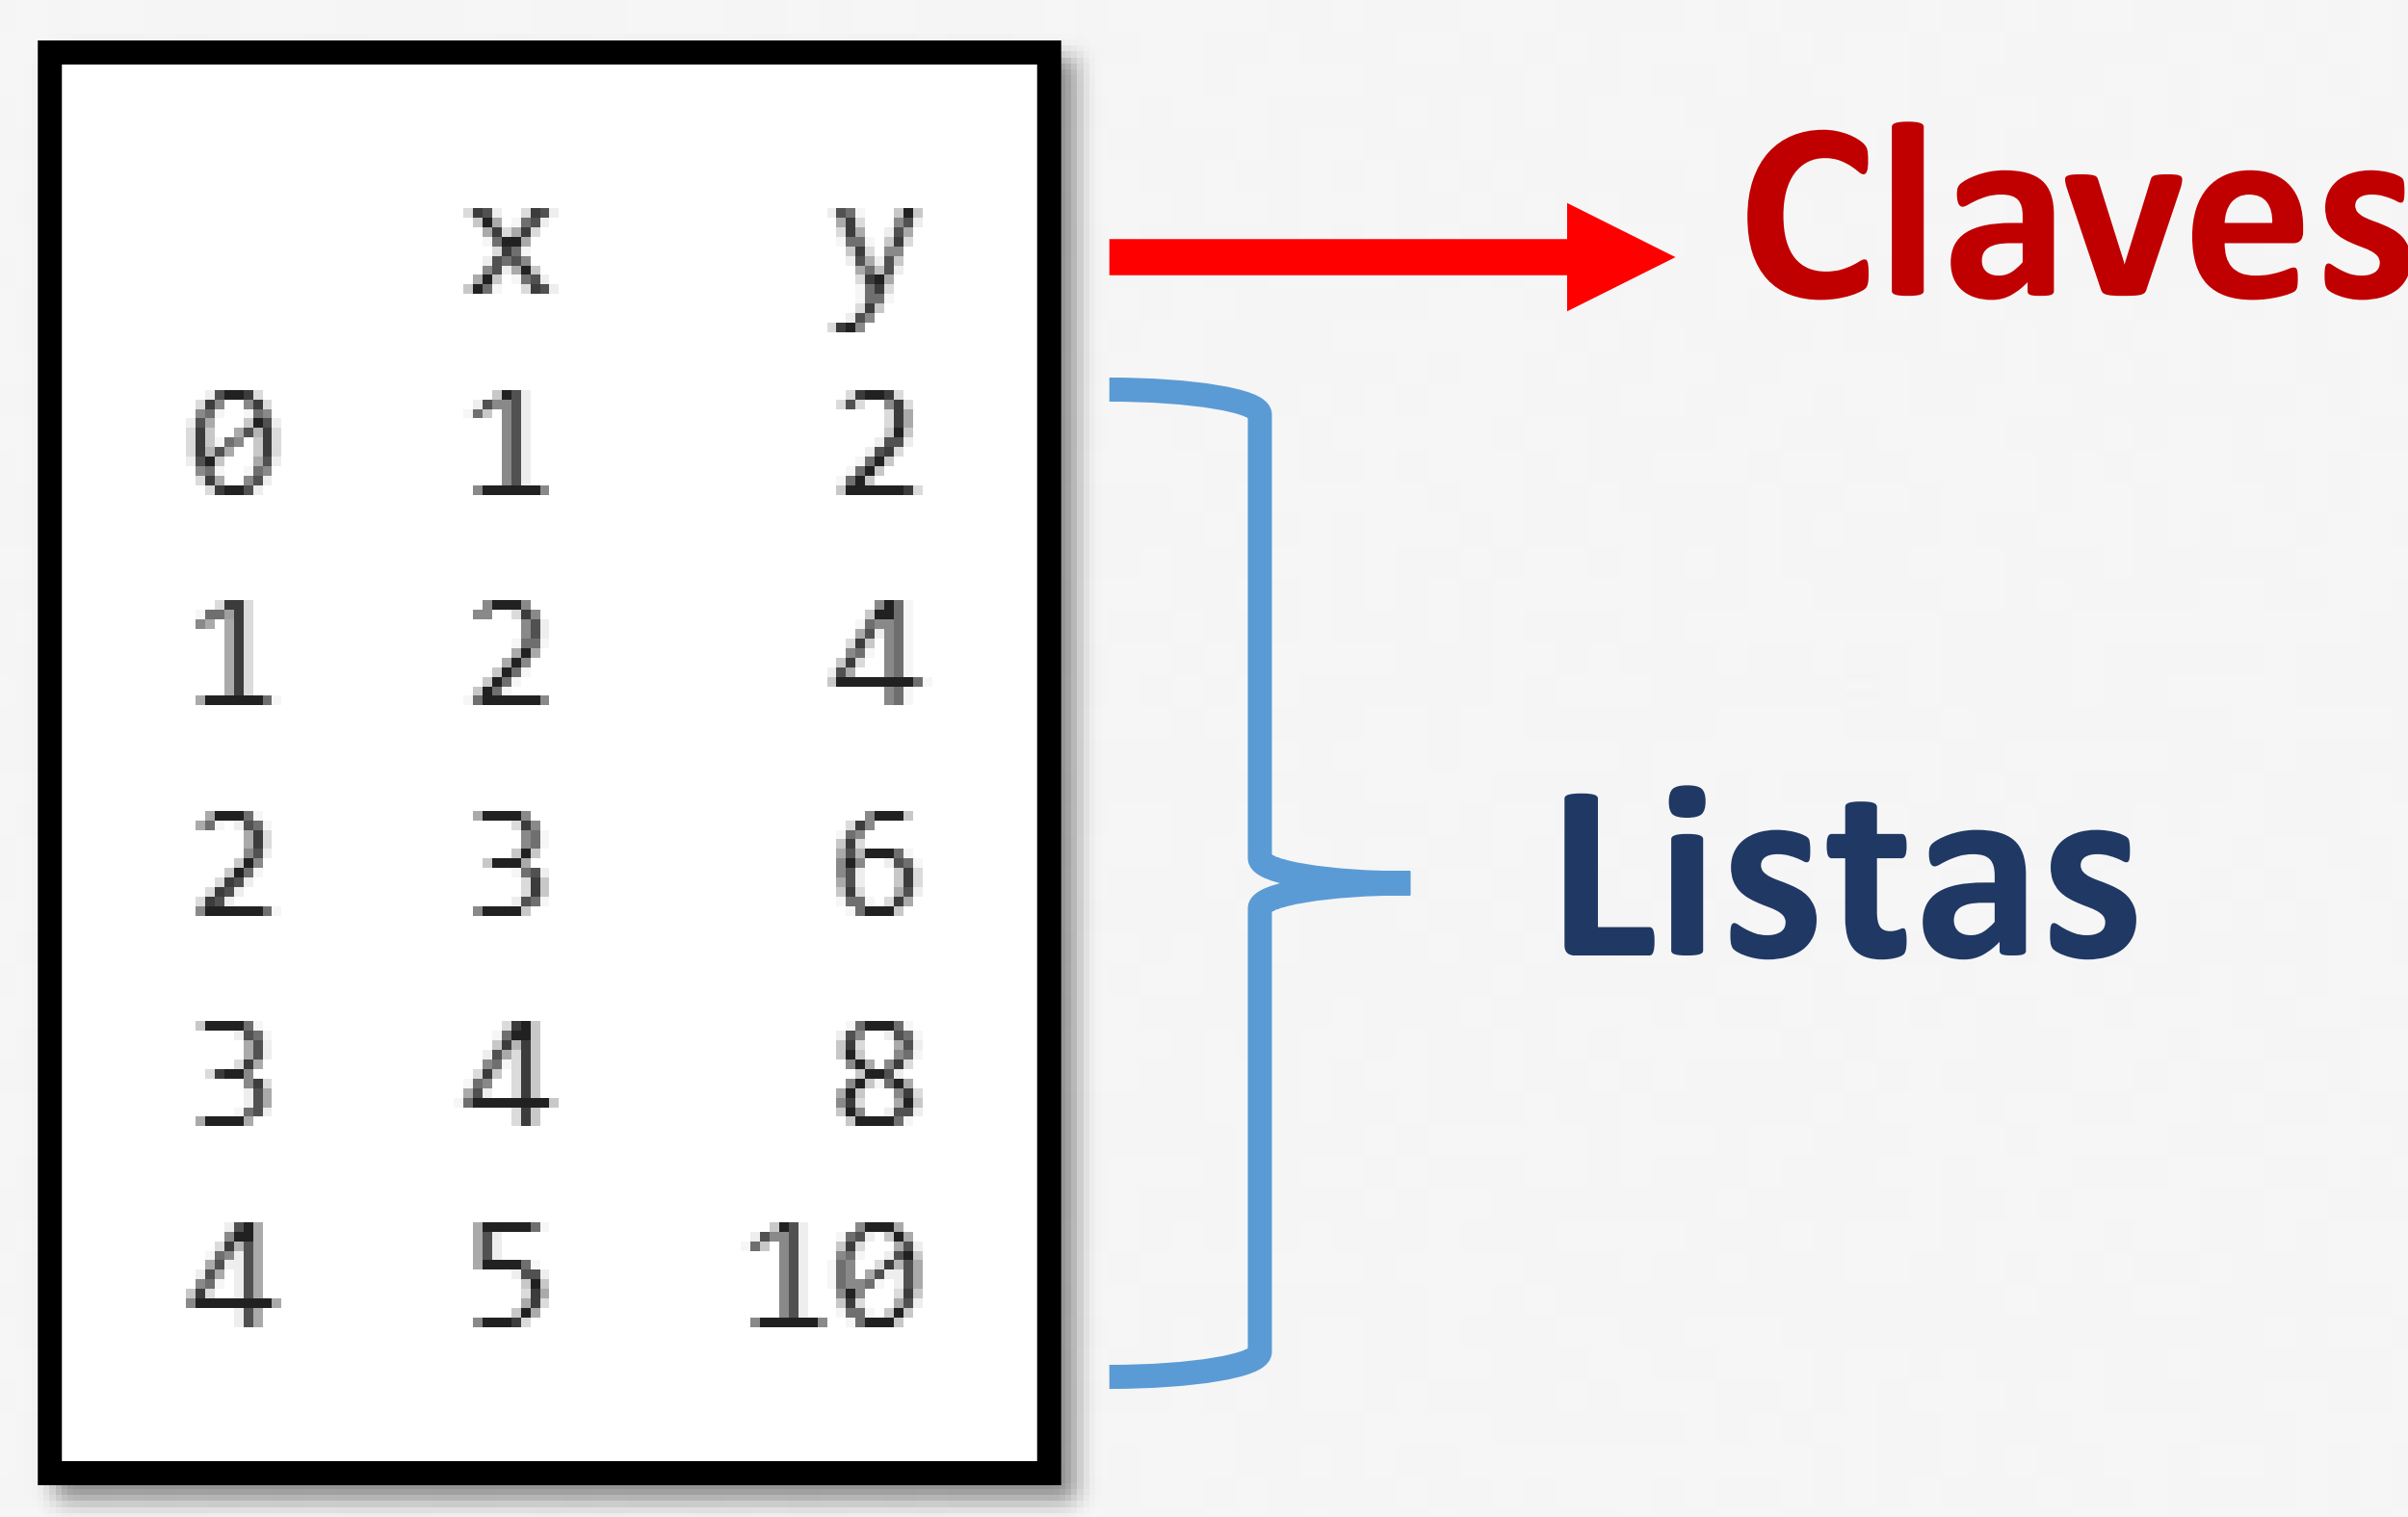</center>

In [13]:
diccionario = {"x": [1, 2, 3, 4, 5], "y": [2, 4, 6, 8, 10]}
diccionario

{'x': [1, 2, 3, 4, 5], 'y': [2, 4, 6, 8, 10]}

In [7]:
type(diccionario)

dict

In [14]:
df1 = pd.DataFrame(data = diccionario)
df1

,x,y
0,1,2
1,2,4
2,3,6
3,4,8
4,5,10


In [9]:
type(df1)

pandas.core.frame.DataFrame

* Los Dataframes pueden crearse usando Listas. En este caso, podemos hacerlo directamente con la función `DataFrame()` de pandas, usando los parámetros **data** y **columns**.

In [12]:
df2 = pd.DataFrame(data = [[1, 2], [2, 4], [3, 6], [4, 8], [5, 10]], columns = ["x", "y"])
df2

,x,y
0,1,2
1,2,4
2,3,6
3,4,8
4,5,10


## **12.1.2. Modificar las etiquetas**

* Cambiar el nombre de las <font color="blue">filas</font>

In [15]:
df3 = pd.DataFrame(data = diccionario, index = ["obs1", "obs2", "obs3", "obs4", "obs5"])
df3

,x,y
obs1,1,2
obs2,2,4
obs3,3,6
obs4,4,8
obs5,5,10


In [16]:
df3.rename(index={'obs1':'primera fila'})

,x,y
primera fila,1,2
obs2,2,4
obs3,3,6
obs4,4,8
obs5,5,10


In [18]:
df3 = df3.rename(index={'obs1':'primera fila'})
df3

,x,y
primera fila,1,2
obs2,2,4
obs3,3,6
obs4,4,8
obs5,5,10


In [19]:
df3.rename(index={'obs5':'ultima fila'},inplace=True)
df3

,x,y
primera fila,1,2
obs2,2,4
obs3,3,6
obs4,4,8
ultima fila,5,10


In [22]:
nomb = {'obs2':'segunda fila','obs3':'tercera fila','obs4':'cuarta fila',}
df3.rename(index=nomb,inplace=True)
df3

,x,y
primera fila,1,2
segunda fila,2,4
tercera fila,3,6
cuarta fila,4,8
ultima fila,5,10


In [29]:
df3.index = ["fila_1", "fila_2", "fila_3", "fila_4", "fila_2"]
df3

,x,y
fila_1,1,2
fila_2,2,4
fila_3,3,6
fila_4,4,8
fila_2,5,10


* Cambiar el nombre de las <font color="red">columnas</font>

In [30]:
df4 = df3.rename(columns={"x": "voltaje", "y": "corriente"})
df4

,voltaje,corriente
fila_1,1,2
fila_2,2,4
fila_3,3,6
fila_4,4,8
fila_2,5,10


In [31]:
df4.rename(columns={"voltaje": "Voltage (mV)", "corriente": "Current (mA)"}, inplace=True)
df4

,Voltage (mV),Current (mA)
fila_1,1,2
fila_2,2,4
fila_3,3,6
fila_4,4,8
fila_2,5,10


In [32]:
df4.columns = ["Variable_A", "Variable_B"]
df4

,Variable_A,Variable_B
fila_1,1,2
fila_2,2,4
fila_3,3,6
fila_4,4,8
fila_2,5,10


## **12.1.3. Explorar el dataset**



El contenido del archivo _Datos.csv_ se encuentran almacenados en el objeto **DataFrame** _df_.

Existen algunos métodos comunes y atributos disponibles para ojear los datos:

1. ```DataFrame.head()```  -> retorna los nombres de las columnas y las primeras 5 filas por defecto
2. ```DataFrame.tail()```  -> retorna los nombres de las columnas y las últimos 5 filas por defecto
3. ```DataFrame.shape```   -> retorna (num_filas, num_columnas)
4. ```DataFrame.columns``` -> retorna los índices de las columnas
5. ```DataFrame.index```   -> retorna los índices de las filas

Recomiendo revisar la [documentación de pandas](https://pandas.pydata.org/pandas-docs/stable/) y explorar los parámetros de estos métodos así como de otros métodos.

Supongamos el siguiente dataset con 100 entradas:

In [34]:
lista_0 = list(range(1, 101))
lista_1 = [x**0.5 for x in lista_0]
lista_2 = [x**2 for x in lista_0]
lista_3 = [x**3 for x in lista_0]

datos = {"x": lista_0, "Raiz": lista_1, "Cuadrado": lista_2, "Cubo": lista_3}
df1 = pd.DataFrame(data = datos)
df1

,x,Raiz,Cuadrado,Cubo
0,1,1.000000,1,1
1,2,1.414214,4,8
2,3,1.732051,9,27
3,4,2.000000,16,64
4,5,2.236068,25,125
...,...,...,...,...
95,96,9.797959,9216,884736
96,97,9.848858,9409,912673
97,98,9.899495,9604,941192
98,99,9.949874,9801,970299


* Mostrar las primeras 5 filas del DataFrame usando el método `.head()`

In [35]:
df1.head()

,x,Raiz,Cuadrado,Cubo
0,1,1.000000,1,1
1,2,1.414214,4,8
2,3,1.732051,9,27
3,4,2.000000,16,64
4,5,2.236068,25,125


`.head(n)` muestra las `'n'` primeras filas del DataFrame

In [42]:
df1.head(10)

,x,Raiz,Cuadrado,Cubo
0,1,1.000000,1,1
1,2,1.414214,4,8
2,3,1.732051,9,27
3,4,2.000000,16,64
4,5,2.236068,25,125
5,6,2.449490,36,216
6,7,2.645751,49,343
7,8,2.828427,64,512
8,9,3.000000,81,729
9,10,3.162278,100,1000


* Mostrar las últimas 5 filas del DataFrame usando el método `.tail()`

In [43]:
df1.tail()

,x,Raiz,Cuadrado,Cubo
95,96,9.797959,9216,884736
96,97,9.848858,9409,912673
97,98,9.899495,9604,941192
98,99,9.949874,9801,970299
99,100,10.000000,10000,1000000


`.tail(n)` muestra las últimas `'n'` filas del DataFrame

In [44]:
df1.tail(3)

,x,Raiz,Cuadrado,Cubo
97,98,9.899495,9604,941192
98,99,9.949874,9801,970299
99,100,10.000000,10000,1000000


* Mostrar solo las columnas de interés, usando las etiquetas

In [51]:
df1[['x','Cuadrado']]

,x,Cuadrado
0,1,1
1,2,4
2,3,9
3,4,16
4,5,25
...,...,...
95,96,9216
96,97,9409
97,98,9604
98,99,9801


In [52]:
df1[['x','Cuadrado']].head()

,x,Cuadrado
0,1,1
1,2,4
2,3,9
3,4,16
4,5,25


* Contar cuántas filas cumplen con una condición específica.

In [56]:
conteo = (df1['Cuadrado']>1000).sum()
print(conteo)

69


*  Mostrar el "tamaño" del **DataFrame** usando el atributo `.shape`

In [57]:
df1.shape

(100, 4)

* Mostrar el título de las columnas del DataFrame usando el atributo `.columns`

In [59]:
df1.columns

Index(['x', 'Raiz', 'Cuadrado', 'Cubo'], dtype='object')

* Mostrar el tipo de elementos de cada columna del DataFrame, usando el atributo `.dtypes`

In [61]:
df1.head()

,x,Raiz,Cuadrado,Cubo
0,1,1.000000,1,1
1,2,1.414214,4,8
2,3,1.732051,9,27
3,4,2.000000,16,64
4,5,2.236068,25,125


In [60]:
df1.dtypes

,0
x,int64
Raiz,float64
Cuadrado,int64
Cubo,int64


A menos que se especifique de otra manera, los objetos DataFrame tienen índices que comienzan en 0 y se incrementan monotónicamente a través de los enteros (esto es tanto para filas como para columnas).

* Mostrar los índices de las filas del DataFrame, usando el atributo `.index`

In [62]:
df1.index

RangeIndex(start=0, stop=100, step=1)

## **12.1.4.  Métodos describe() e info()**

* Mostrar información básica del **DataFrame**, usando el método `.info()`

El método `.info()` muestra los nombres de columnas, cantidad de valores no nulos, tipos de datos (int, float, object) y cuánto pesa el archivo en memoria.

Es util para ver si es necesario limpiar datos o cambiar tipos de variables.

In [63]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   x         100 non-null    int64  
 1   Raiz      100 non-null    float64
 2   Cuadrado  100 non-null    int64  
 3   Cubo      100 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 3.3 KB


* Mostrar estadísticas descriptivas del DataFrame, usando el método `.describe()`

Muestra el conteo, promedio (mean), desviación estándar, valor mínimo, valor máximo y los cuartiles (25%, 50%, 75%).

El util para entender la distribución de los datos (por ejemplo, ver rápidamente cuál es el máximo de muertes o el promedio de casos activos).

In [64]:
df1.describe()

,x,Raiz,Cuadrado,Cubo
count,100.000000,100.000000,100.000000,100.000000
mean,50.500000,6.714629,3383.500000,255025.000000
std,29.011492,2.338469,3024.355854,289320.678688
min,1.000000,1.000000,1.000000,1.000000
25%,25.750000,5.074265,663.250000,17088.250000
50%,50.500000,7.106248,2550.500000,128825.500000
75%,75.250000,8.674640,5662.750000,426150.250000
max,100.000000,10.000000,10000.000000,1000000.000000


## **12.1.5.  Métodos isnull() y duplicated()**

* Mostrar el conteo de valores nulos, usando el método `.isnull().sum()`

In [65]:
df1.isnull().sum()

,0
x,0
Raiz,0
Cuadrado,0
Cubo,0


* Mostrar el conteo de valores duplicados, usando el método `.duplicated().sum()`

In [67]:
df1.duplicated().sum()

np.int64(0)

## **12.1.6. Cargar un DataFrame desde un archivo `.csv`**

In [127]:
df = pd.read_csv("https://raw.githubusercontent.com/cgl-itm/ProgramacionAvanzada-ITM/main/notebooks/Datos.csv")
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [ ]:
df2 = pd.read_csv("https://raw.githubusercontent.com/cgl-itm/ProgramacionAvanzada-ITM/main/notebooks/Datos.csv", header=None)
df2.head()

* Es posible utilizar una de las columnas existentes como etiqueta pora las filas.

In [130]:
df = pd.read_csv("https://raw.githubusercontent.com/cgl-itm/ProgramacionAvanzada-ITM/main/notebooks/Datos.csv", index_col=0)
df.head()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
Country/Region,,,,,,,,,,,,,,
Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


****

In [132]:
df.head()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
Country/Region,,,,,,,,,,,,,,
Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


* Mostrar solo las columnas de interés

In [134]:
df3 = df[['Deaths','Deaths / 100 Cases']]
df3

,Deaths,Deaths / 100 Cases
Country/Region,,
Afghanistan,1269,3.50
Albania,144,2.95
Algeria,1163,4.16
Andorra,52,5.73
Angola,41,4.32
...,...,...
West Bank and Gaza,78,0.73
Western Sahara,1,10.00
Yemen,483,28.56


In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 187 entries, Afghanistan to Zimbabwe
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Confirmed               187 non-null    int64  
 1   Deaths                  187 non-null    int64  
 2   Recovered               187 non-null    int64  
 3   Active                  187 non-null    int64  
 4   New cases               187 non-null    int64  
 5   New deaths              187 non-null    int64  
 6   New recovered           187 non-null    int64  
 7   Deaths / 100 Cases      187 non-null    float64
 8   Recovered / 100 Cases   187 non-null    float64
 9   Deaths / 100 Recovered  187 non-null    float64
 10  Confirmed last week     187 non-null    int64  
 11  1 week change           187 non-null    int64  
 12  1 week % increase       187 non-null    float64
 13  WHO Region              187 non-null    object 
dtypes: float64(4), int64(9), object(

In [136]:
df.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02,187.000000,187.000000,187.000000,187.000000,187.000000,187.00,1.870000e+02,187.000000,187.000000
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04,1222.957219,28.957219,933.812834,3.019519,64.820535,inf,7.868248e+04,9448.459893,13.606203
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05,5710.374790,120.037173,4197.719635,3.454302,26.287694,NaN,3.382737e+05,47491.127684,24.509838
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,1.000000e+01,-47.000000,-3.840000
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02,4.000000,0.000000,0.000000,0.945000,48.770000,1.45,1.051500e+03,49.000000,2.775000
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03,49.000000,1.000000,22.000000,2.150000,71.320000,3.62,5.020000e+03,432.000000,6.890000
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03,419.500000,6.000000,221.000000,3.875000,86.885000,6.44,3.708050e+04,3172.000000,16.855000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,28.560000,100.000000,inf,3.834677e+06,455582.000000,226.320000


In [137]:
df.columns

Index(['Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths',
       'New recovered', 'Deaths / 100 Cases', 'Recovered / 100 Cases',
       'Deaths / 100 Recovered', 'Confirmed last week', '1 week change',
       '1 week % increase', 'WHO Region'],
      dtype='object')

In [138]:
df.index

Index(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria',
       ...
       'United Kingdom', 'Uruguay', 'Uzbekistan', 'Venezuela', 'Vietnam',
       'West Bank and Gaza', 'Western Sahara', 'Yemen', 'Zambia', 'Zimbabwe'],
      dtype='object', name='Country/Region', length=187)

In [140]:
(df['Deaths']>1000).sum()

np.int64(44)

In [141]:
type(df)
#print(df)

pandas.core.frame.DataFrame

In [142]:
df.shape

(187, 14)

In [143]:
df.dtypes

,0
Confirmed,int64
Deaths,int64
Recovered,int64
Active,int64
New cases,int64
New deaths,int64
New recovered,int64
Deaths / 100 Cases,float64
Recovered / 100 Cases,float64
Deaths / 100 Recovered,float64


In [144]:
for i in df.columns:
  print(i)

Confirmed
Deaths
Recovered
Active
New cases
New deaths
New recovered
Deaths / 100 Cases
Recovered / 100 Cases
Deaths / 100 Recovered
Confirmed last week
1 week change
1 week % increase
WHO Region


## **12.1.7.  Columnas como objetos**

In [145]:
df.head()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
Country/Region,,,,,,,,,,,,,,
Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


* Para referirse a las columnas se pueden llamar como objetos de python. Por ejemplo:


In [147]:
df.columns

Index(['Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths',
       'New recovered', 'Deaths / 100 Cases', 'Recovered / 100 Cases',
       'Deaths / 100 Recovered', 'Confirmed last week', '1 week change',
       '1 week % increase', 'WHO Region'],
      dtype='object')

* TAB para autocompletado dinámico

In [107]:
df.Recovered

,Recovered
0,25198
1,2745
2,18837
3,803
4,242
...,...
182,3752
183,8
184,833
185,2815


* Si el nombre de una columna no tiene espacios (ni caracteres especiales) se puede llamar como un atributo:

In [111]:
df.Recovered
#df.Country/Region
#df.New cases

,Recovered
0,25198
1,2745
2,18837
3,803
4,242
...,...
182,3752
183,8
184,833
185,2815


In [ ]:
#df.Deaths / 100 Cases
#df['Deaths / 100 Cases']

* Podemos cambiar nombres de columnas (o filas)

In [149]:
df.rename(columns = {'Deaths':'Muertos','Active':'Activos', 'Recovered':'Recuperados', 'New cases':'new_cases'}, inplace=True)
df

,Confirmed,Muertos,Recuperados,Activos,new_cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
Country/Region,,,,,,,,,,,,,,
Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
West Bank and Gaza,10621,78,3752,6791,152,2,0,0.73,35.33,2.08,8916,1705,19.12,Eastern Mediterranean
Western Sahara,10,1,8,1,0,0,0,10.00,80.00,12.50,10,0,0.00,Africa
Yemen,1691,483,833,375,10,4,36,28.56,49.26,57.98,1619,72,4.45,Eastern Mediterranean


In [150]:
df.new_cases

,new_cases
Country/Region,
Afghanistan,106
Albania,117
Algeria,616
Andorra,10
Angola,18
...,...
West Bank and Gaza,152
Western Sahara,0
Yemen,10


In [153]:
df.head()

,Confirmed,Muertos,Recuperados,Activos,new_cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
Country/Region,,,,,,,,,,,,,,
Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [158]:
nomb = {'Andorra':'andorra'}
df.rename(index=nomb,inplace=True)
df.head()

,Confirmed,Muertos,Recuperados,Activos,new_cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
Country/Region,,,,,,,,,,,,,,
Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [159]:
type(df['new_cases'])

pandas.core.series.Series

In [ ]:
type(df[['new_cases']])

In [ ]:
print(type(df.Muertos))
print(type(df['Muertos']))
print(type(df[['Muertos']]))
print(type(df))

In [ ]:
df['Muertos']

## **12.2.  Slicing**

### **12.2.1.  Slicing de Python 'puro'**

In [ ]:
df

Se puede hacer **slicing** usando la misma sintaxis usada con `numpy`, sin embargo, funciona únicamente funciona para filas.

Sin embargo, no se recomienda hacerlo, ya que puede llevar a errores.

In [ ]:
df[:7]
#df[180:]
#df[1:5]
#df[1:5:2]

### **12.2.2.  Slicing usando `.loc` y `.iloc`**

**Etiqueta vs. Posición**

* Index/Row Label (**Etiqueta**): Es el nombre que tú le asignas (como 'zero', 'one'). Es lo que identificamos con el atributo .index.

* Index/Row Position (**Posición**): Es el orden físico en la memoria, empezando siempre desde 0 hasta n-1, sin importar el nombre que tenga la fila.

![](https://miro.medium.com/max/720/1*bEUFOBKEvgZnmBbEPyK3tg.png)


**.loc** vs **.iloc**


* `.loc` (Label-based): Se usa para seleccionar por el nombre.

En los rangos (slicing), incluye el último elemento. Si pides 'zero':'two', te traerá tres filas: zero, one y two.

* `.iloc` (Integer-position based): Se usa para seleccionar por el número de posición.

Sigue la lógica estándar de Python; el último elemento está excluido. Si pides 0:2, solo te traerá las posiciones 0 y 1.

![](https://miro.medium.com/max/720/1*dYtynwab99wnMqfgyPUd3w.png)

In [ ]:
df.head(10)

In [ ]:
df.iloc[2:7]

In [ ]:
df.loc['Algeria':'Argentina']
#df.loc[:'Argentina']

### **12.2.2.  Slicing de columnas (`.iloc`)**

Si se desea hacer slicing también por columnas, es mejor usar el atributo `iloc` con índices (posiciones)

In [ ]:
help(df.iloc)

In [ ]:
# df.iloc[filas,columnas]
df.iloc[:,3:]

In [ ]:
df.iloc[2:5:2,1:8:3]

In [ ]:
help(df.loc)

In [ ]:
df.columns

* Para hacer slicing también por columnas, se puede usar el atributo `loc` con nombres de columnas

In [ ]:
df.loc['Albania':'Belgium',['Activos', 'Confirmed', 'new_cases']] #Notar que loc  sí incluye el último valor

In [ ]:
df.loc[:'Azerbaijan',:]

### **12.2.3. Slicing con relaciones**

In [ ]:
df['Muertos'] > 400

In [ ]:
df[df['Muertos'] > 400]

In [ ]:
# Qué paises de América presentaron más de 500 casos nuevos y un porcentaje
# de incremento semanal mayor al 10%

#Se recomienda separar cada condición con paréntesis para evitar errores
df[(df['WHO Region'] == 'Americas') & (df.new_cases > 500) & (df['1 week % increase'] > 10)]


## Aritmética Simple

Como numpy, los objetos de pandas tienen sobrecargados operaciones aritméticas básicas, como +, -,*, /, ***.

In [ ]:
print(df.Muertos[1:5])
print(df.Muertos[1:5]*10)
print(df.Muertos[1:5]/10)
print(df.Muertos[1:5]+df.Muertos[1:5])
print(df.Muertos[1:5]**2)

In [ ]:
df.head(2)

In [ ]:
df.iloc[0,:-1] *= 10

In [ ]:
df

## Crear columnas adicionales

In [ ]:
df

In [ ]:
df['Relacion'] = (df['Confirmed'] - df['Muertos'])*100/df.Confirmed

In [ ]:
df

## Remover columnas

In [ ]:
df.drop('Relacion',axis=1)
df

In [ ]:
df.Relacion

In [ ]:
df.drop('andorra',axis=0, inplace=True)
df

In [ ]:
df.loc['Zimbabwe','Muertos'] = 3500
#df2.Muertos = 0
df

## Estadística Descriptiva

Para la mayoría de estadísticas descriptivas, pandas provee métodos:

In [ ]:
df['new_cases'].sum()

## Ejemplo de datos con distribucion Normal

In [ ]:
datos = np.random.randn(1000)
datos2 = pd.DataFrame(datos)
datos2.boxplot()

## Ejercicio
Encontrar cual es el pais con la menor y mayor cantidad de Muertos

## Ejercicio

Encontrar la cantidad de casos confirmados menores a 4 millones

## Ejercicio
Organizar los datos de acuerdo a la cantidad de Muertos y graficar los primeros 5 paises con la cantidad de Muertos.

In [ ]:
df3 = df.copy()
df3['Confirmed'].loc['Holy See'] = 10
df3['Muertos'].loc['Holy See'] = 2
df3.sort_values(by=['Confirmed','Muertos'])

In [ ]:
sernueva = df['Confirmed last week'].sort_values(ascending = False)

In [ ]:
sernueva[:30].plot.bar(figsize = (8,8))

In [ ]:
print('Promedio             ', df.Activos.mean())
print('Desviación estándar  ', df.Activos.std())
print('Mediana              ', df.Activos.median())
print('Mínimo               ', df.Activos.min())
print('Máximo               ', df.Activos.max())

## Gráficas a partir de DataFrames

In [ ]:
plt.figure()
plt.scatter(df['new_cases'], df['New deaths'], color='red', alpha=0.6)
plt.ylabel('Nuevas muertes')
plt.xlabel('Nuevos Casos')
plt.grid()
plt.show()

In [ ]:
plt.figure(figsize=(12,6))
ax = df.plot.scatter(x='new_cases',y='New deaths')
ax.grid()
plt.show()

In [ ]:
plt.figure(figsize=(16,9))
plt.plot(df['Muertos'][:5], color='red', alpha=0.6)
plt.ylabel('Muertos')
# plt.grid()
plt.show()

In [ ]:
plt.figure(figsize=(40,6))
plt.plot(np.arange(186),df['new_cases'],'ro')
plt.xticks(np.arange(186),df.index,rotation='vertical');

In [ ]:
plt.figure(figsize=(20,4))
ax = df['new_cases'].plot(xticks=np.arange(186)[::3], rot=70)
#ax.set_xticklabels(df.index[::3]);

In [ ]:
arreglo = df.loc['Albania':'Belgium',['Activos', 'Confirmed', 'new_cases']].values #Notar que loc  sí incluye el último valor

In [ ]:
arreglo

In [ ]:
df20 = df.loc['Albania':'Belgium',['Activos', 'Confirmed', 'new_cases']]

In [ ]:
arreglo

In [ ]:
df[(df.index > 'T') & (df.index < 'U')] #regex: expresiones regulares

In [ ]:
df[df.index.str.contains('^T',regex=True)]

## Guardar un DataFrame como un archivo csv

In [ ]:
print(df.shape)
df.tail()

In [ ]:
df.to_csv('clasePandas.csv')

In [ ]:
df.loc['Albania':'Belgium',['Activos', 'Confirmed', 'new_cases']].to_html('base.html')

$ y  = \frac{1}{2}$

## O a excel

In [ ]:
df.to_excel?

In [ ]:
# df.to_excel('archivo.xlsx')
df.to_excel('archivo.xlsx', sheet_name='Datos Covid Noviembre')

# Ejercicios propuestos

1. Encontrar los países que tengan más de 5000 casos activos y calcule el promedio de casos activos para esos países.

2. Encontrar el país que tenga la mayor cantidad de casos recuperados (revisar el método idxmax)

3. Encontrar el país con el mayor incremento porcentual en 1 semana


In [ ]:
print(df[df['Activos']>5000].index)
print(df[df['Activos']>5000].Activos.mean())

In [ ]:
df['Recuperados'].idxmax()

In [ ]:
df['1 week % increase'].idxmax()

Dentro de los 10 primeros paises con la mayor cantidad de Confirmados, seleccionar el que tenga la menor cantidad de recuperados.

In [ ]:
#Como no se debe hacer
df.sort_values(by='Confirmed',
               ascending = False).loc[df.sort_values(by='Confirmed',ascending = False).index[0]:
                                      df.sort_values(by='Confirmed', ascending = False).index[10],
                                      'Recuperados'].idxmax()

In [ ]:
df.sort_values(by='Confirmed', ascending = False)[:10].loc[:,'Recuperados'].idxmax()

In [ ]:
#La columna 2 es la de recuperados
df.sort_values(by='Confirmed', ascending = False).iloc[:10,2].idxmax()

In [ ]:
df.sort_values(by='Confirmed', ascending = False).loc[:,'Recuperados'].iloc[:10].idxmax()

## Sugerencias:

- https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html
- https://www.learndatasci.com/tutorials/python-pandas-tutorial-complete-introduction-for-beginners/